# Arkusz ćwiczeń - regresja logistyczna

### Część I - pytania kontrolne
1. Różnica między regresją liniową a logistyczną  
Regresja liniowa służy do przewidywania wartości ciągłych, natomiast regresja logistyczna jest stosowana do klasyfikacji binarnej. Zamiast bezpośrednio przewidywać wartość, model logistyczny zwraca prawdopodobieństwo przynależności do klasy, ograniczone do przedziału [0,1] dzięki funkcji sigmoidalnej.

2. Znaczenie funkcji sigmoidalnej  
Funkcja sigmoidalna przekształca dowolną wartość rzeczywistą (logit) do zakresu od 0 do 1. Interpretujemy ją jako prawdopodobieństwo przynależności do klasy pozytywnej.

3. Interpretacja θ₀ i θ₁  
θ₀ (intercept) określa bazowy logit, czyli wartość modelu przy wszystkich cechach równych 0.  
θ₁ (współczynnik kierunkowy) określa wpływ zmiennej niezależnej na logit - jego znak wskazuje kierunek wpływu, a wartość bezwzględna siłę tego wpływu.

4. Logit i jego zależność z prawdopodobieństwem  
Logit to logarytm ilorazu szans:
logit(p) = log(p / (1 - p)) 
Łączy on prawdopodobieństwo z liniową kombinacją cech w modelu. Model regresji logistycznej działa liniowo w przestrzeni logitów, a dopiero potem przekształca wynik do prawdopodobieństwa.

5. Iloraz szans (odds ratio)  
Iloraz szans (odds ratio) to exp(θ), czyli wykładnik współczynnika regresji logistycznej. Informuje, jak zmieniają się szanse zdarzenia przy jednostkowej zmianie cechy. Wartość >1 oznacza wzrost szans, a <1 ich spadek.

6. AUC-ROC  
AUC-ROC mierzy zdolność modelu do rozróżniania klas. Wartość 1 oznacza idealną separację, 0.5 oznacza brak lepszej jakości niż losowe zgadywanie. Im wyższe AUC, tym lepszy model klasyfikacyjny.

7. Standaryzacja danych  
Standaryzacja jest ważna, ponieważ regresja logistyczna jest wrażliwa na skalę cech. Ujednolicenie zakresów zmiennych poprawia stabilność numeryczną modelu i sprawia, że współczynniki są porównywalne.

8. Kalibracja modelu  
Kalibrację ocenia się poprzez porównanie przewidywanych prawdopodobieństw z rzeczywistymi częstościami zdarzeń. Wykorzystuje się m.in. krzywe kalibracji oraz metryki takie jak Brier score - im niższy, tym lepsza kalibracja.

### Część II - ćwiczenia praktyczne w Pythonie

1. Wczytaj dane z pliku `data.xlsx` i wyświetl pierwsze 5 wierszy.

In [3]:
import pandas as pd

df = pd.read_excel("data.xlsx")

print(df.head())

   target  age  smoke
0       0   20      0
1       1   21      0
2       0   22      0
3       0   23      0
4       0   24      1


2. Zbuduj model regresji logistycznej z wykorzystaniem
`sklearn.linear_model.LogisticRegression`

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

3. Naucz model na podstawie zmiennej `age` i celu `target`.

In [5]:
X = df[["age"]]
y = df["target"]

model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

4. Odczytaj współczynniki modelu: `intercept_` i `coef_`.

In [6]:
print("Intercept:", model.intercept_)
print("Coef:", model.coef_)

Intercept: [-3.61773187]
Coef: [[0.05625816]]


5. Oblicz prawdopodobieństwo zdarzenia dla wieku = 30 lat, używając `predict_proba()`.

In [7]:
import numpy as np

age_test = np.array([[30]])
prob_30 = model.predict_proba(age_test)[0, 1]

print(prob_30)

0.1267520211098006


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


6. Zastosuj wzór matematyczny sigmoidy i porównaj wynik z `predict_proba()`.

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = model.intercept_[0] + model.coef_[0][0] * 30
sig_value = sigmoid(z)

print("Sigmoid:", sig_value)
print("Predict_proba:", prob_30)

Sigmoid: 0.1267520211098006
Predict_proba: 0.1267520211098006


7. Oblicz miary jakości modelu: AUC i Brier Score.

In [9]:
from sklearn.metrics import roc_auc_score, brier_score_loss

p = model.predict_proba(X)[:, 1]

auc = roc_auc_score(y, p)
brier = brier_score_loss(y, p)

print("AUC:", auc)
print("Brier:", brier)

AUC: 0.8071253071253072
Brier: 0.17599413155905824


8. Narysuj wykres funkcji sigmoidalnej oraz zaznacz na nim punkty dla kilku wybranych
wartości wieku (np. 20, 30, 40, 50, 60)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


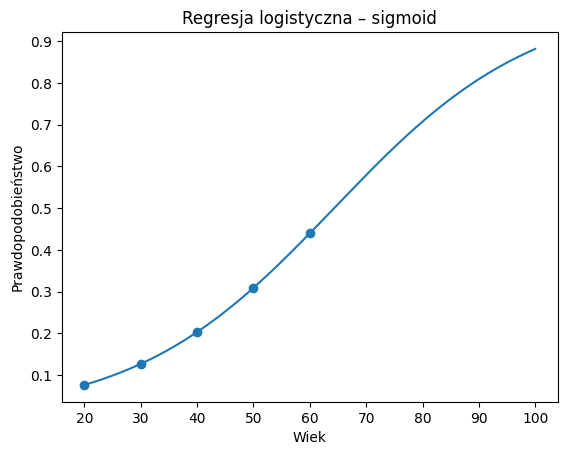

In [10]:
import matplotlib.pyplot as plt

ages = np.linspace(20, 100, 200)

z_vals = model.intercept_[0] + model.coef_[0][0] * ages
p_vals = sigmoid(z_vals)

plt.plot(ages, p_vals)

points = np.array([20, 30, 40, 50, 60])
p_points = model.predict_proba(points.reshape(-1,1))[:,1]

plt.scatter(points, p_points)

plt.xlabel("Wiek")
plt.ylabel("Prawdopodobieństwo")
plt.title("Regresja logistyczna – sigmoid")
plt.show()

9. Zinterpretuj wykres – w jaki sposób zmiana wieku wpływa na prawdopodobieństwo
zdarzenia?

Wykres pokazuje nieliniową zależność między wiekiem a prawdopodobieństwem zdarzenia. Wraz ze wzrostem wieku prawdopodobieństwo rośnie zgodnie z funkcją sigmoidalną - powoli dla niskich wartości, szybciej w środku zakresu i ponownie wolniej przy wysokich wartościach.

Wiek ma dodatni wpływ na ryzyko zdarzenia.

### Część III – Analiza wyników i wnioski
Na podstawie otrzymanych wyników odpowiedz na poniższe pytania:

**1. Jak zmienia się prawdopodobieństwo zdarzenia wraz z wiekiem?**  
Prawdopodobieństwo zdarzenia rośnie wraz z wiekiem. Model pokazuje dodatnią, ale umiarkowaną zależność - stosunkowo niskie ryzyko w młodszym wieku, które stopniowo rośnie wraz z wiekiem zgodnie z funkcją sigmoidalną.

**2. Czy współczynnik θ₁ jest dodatni czy ujemny i co to oznacza?**  
Współczynnik `Coef` przy zmiennej age jest dodatni (0.056), co oznacza, że wzrost wieku zwiększa logit, a więc również prawdopodobieństwo zdarzenia. Innymi słowy, im starsza osoba, tym większe ryzyko wystąpienia zdarzenia.

**3. Czy model jest dobrze dopasowany do danych? Jakie wnioski można wyciągnąć z wartości AUC?**  
Wartość AUC = 0.807 wskazuje na dobrą, ale nie idealną zdolność modelu do rozróżniania klas. Oznacza to, że model w ok. 80% przypadków poprawnie odróżnia osoby z i bez zdarzenia.

**4. Jakie są ograniczenia tego modelu w kontekście prognozowania?**  
Model wykorzystuje tylko jedną zmienną (wiek), co ogranicza jego zdolność predykcyjną. W rzeczywistości ryzyko zdarzenia może zależeć również od innych czynników, takich jak palenie (`smoke`), stan zdrowia czy styl życia.


### Wnioski końcowe

Prawdopodobieństwo zdarzenia rośnie wraz z wiekiem, co potwierdza dodatni współczynnik przy zmiennej age. Model pokazuje umiarkowaną jakość predykcji i dobrze rozróżnia przypadki, ale nie jest idealny.